# stagev5 result audit

Display-only notebook for the completed stagev5 experiment. It reads existing CSV, JSON, Markdown, and PNG files only; it does not train models, extract E/M/L features, or call APIs.

## 1. Experiment identity

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path.cwd().resolve()
if not (ROOT / 'output').exists() and (ROOT.parent / 'output').exists():
    ROOT = ROOT.parent.resolve()
FINAL = ROOT / 'output' / 'final_report'
FIG = FINAL / 'figures'

IDENTITY = pd.DataFrame([{
    'project': 'stagev5',
    'task': 'Cookie Theft AD vs control binary classification',
    'classifier_panel': 'stagev2 classifier panel',
    'cv_protocol': '10-fold CV (10x1)',
    'selection_metric': 'external_accuracy',
    'bootstrap_n': 200,
    'project_root': str(ROOT),
    'final_report_dir': str(FINAL),
}])
display(IDENTITY)

,project,task,classifier_panel,cv_protocol,selection_metric,bootstrap_n,project_root,final_report_dir
0,stagev5,Cookie Theft AD vs control binary classification,stagev2 classifier panel,10-fold CV (10x1),external_accuracy,200,D:\research\H.L.Liang-Lab\Code\Github\stagev5,D:\research\H.L.Liang-Lab\Code\Github\stagev5\...


In [2]:
def read_csv(name):
    path = FINAL / name
    if not path.exists():
        display(Markdown(f'**File not found / not generated yet:** `{path.relative_to(ROOT)}`'))
        return pd.DataFrame()
    return pd.read_csv(path)


def read_json(name):
    path = FINAL / name
    if not path.exists():
        display(Markdown(f'**File not found / not generated yet:** `{path.relative_to(ROOT)}`'))
        return {}
    return json.loads(path.read_text(encoding='utf-8'))


def show_md(name):
    path = FINAL / name
    if path.exists():
        display(Markdown(path.read_text(encoding='utf-8')))
    else:
        display(Markdown(f'**File not found / not generated yet:** `{path.relative_to(ROOT)}`'))


def show_png(name, title=None):
    path = FIG / name
    if path.exists():
        display(Markdown(f'### {title or name}'))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f'**Figure not found / not generated yet:** `{path.relative_to(ROOT)}`'))


def first_existing(*names):
    for name in names:
        path = FINAL / name
        if path.exists():
            return path
    return None

## 2. Feature source audit

In [3]:
manifest = read_json('stagev5_feature_source_manifest.json')
rows = [{
    'E source': 'stagev2.zip early feature extraction',
    'M source': 'stagev2.zip middle feature extraction',
    'L source': 'stagev4_unmasked_form_comparator.zip late P4 unmasked F8 extraction',
    'adapter role': 'aligns IDs, columns, manifests, and model blocks only',
}]
if manifest:
    status = manifest.get('E', {}).get('feature_status', {}) or manifest.get('M', {}).get('feature_status', {}) or manifest.get('L', {}).get('feature_status', {})
    l_info = manifest.get('L', {})
    rows[0].update({
        'E model features': status.get('n_E') or status.get('actual_E'),
        'M model features': status.get('n_M') or status.get('actual_M'),
        'L raw F8 model features': l_info.get('late_model_feature_count') or status.get('late_model_feature_count'),
        'L auxiliary diagnostic features': l_info.get('late_diagnostic_column_count') or status.get('late_diagnostic_column_count'),
        'L auxiliary used in model': l_info.get('late_auxiliary_used_in_model'),
    })
else:
    rows[0].update({
        'E model features': 'file not found / not generated yet',
        'M model features': 'file not found / not generated yet',
        'L raw F8 model features': 'file not found / not generated yet',
        'L auxiliary diagnostic features': 'file not found / not generated yet',
    })
display(pd.DataFrame(rows))

,E source,M source,L source,adapter role,E model features,M model features,L raw F8 model features,L auxiliary diagnostic features,L auxiliary used in model
0,stagev2.zip early feature extraction,stagev2.zip middle feature extraction,stagev4_unmasked_form_comparator.zip late P4 u...,"aligns IDs, columns, manifests, and model bloc...",61,1024,8,0,False


## 3. Existing output availability check

In [4]:
required = [
    'stagev5_model_ranking_by_external_accuracy.csv',
    'stagev5_external_performance_report.csv',
    'stagev5_cv_summary.csv',
    'stagev5_bootstrap_ci.csv',
    'stagev5_generalization_gap.csv',
    'stagev5_test_predictions_all_models.csv',
    'stagev5_stage_subgroup_accuracy.csv',
    'stagev5_error_analysis.csv',
    'stagev5_selected_model_summary.md',
    'stagev5_experiment_report.md',
    'stagev5_feature_source_manifest.json',
    'stagev5_leakage_check.json',
]
availability = pd.DataFrame([
    {'artifact': name, 'available': (FINAL / name).exists(), 'path': str((FINAL / name).relative_to(ROOT))}
    for name in required
])
display(availability)

,artifact,available,path
0,stagev5_model_ranking_by_external_accuracy.csv,True,output\final_report\stagev5_model_ranking_by_e...
1,stagev5_external_performance_report.csv,True,output\final_report\stagev5_external_performan...
2,stagev5_cv_summary.csv,True,output\final_report\stagev5_cv_summary.csv
3,stagev5_bootstrap_ci.csv,True,output\final_report\stagev5_bootstrap_ci.csv
4,stagev5_generalization_gap.csv,True,output\final_report\stagev5_generalization_gap...
5,stagev5_test_predictions_all_models.csv,True,output\final_report\stagev5_test_predictions_a...
6,stagev5_stage_subgroup_accuracy.csv,True,output\final_report\stagev5_stage_subgroup_acc...
7,stagev5_error_analysis.csv,True,output\final_report\stagev5_error_analysis.csv
8,stagev5_selected_model_summary.md,True,output\final_report\stagev5_selected_model_sum...
9,stagev5_experiment_report.md,True,output\final_report\stagev5_experiment_report.md


## 4. Model ranking by external accuracy

,model_name,group,feature_block,accuracy,balanced_accuracy,sensitivity,specificity,f1,roc_auc,pr_auc,mcc
0,early_middle__svc__poly3,two_stage_raw,early_middle,0.845070,0.846429,0.942857,0.750000,0.857143,0.855556,0.849592,0.704702
1,early_middle_scale__svc__poly3,sequential_scale,early_middle_scale,0.830986,0.832143,0.914286,0.750000,0.842105,0.848413,0.833528,0.672338
2,all__svc__poly3,three_stage_raw,all,0.816901,0.818254,0.914286,0.722222,0.831169,0.851587,0.845819,0.647389
3,middle_late_scale__svc__poly3,sequential_scale,middle_late_scale,0.802817,0.804365,0.914286,0.694444,0.820513,0.825397,0.823629,0.622726
4,middle__svc__poly3,single_stage_middle_moderate,middle,0.802817,0.803968,0.885714,0.722222,0.815789,0.846825,0.855089,0.615306
5,all__svc__poly2,three_stage_raw,all,0.788732,0.790476,0.914286,0.666667,0.810127,0.842857,0.837472,0.598298
6,early_middle__lr__l2,two_stage_raw,early_middle,0.788732,0.790476,0.914286,0.666667,0.810127,0.824603,0.822862,0.598298
7,middle__svc__rbf,single_stage_middle_moderate,middle,0.788732,0.790079,0.885714,0.694444,0.805195,0.847619,0.861811,0.590077
8,middle_late__svc__poly3,two_stage_raw,middle_late,0.788732,0.790079,0.885714,0.694444,0.805195,0.843651,0.851695,0.590077
9,all_plus_interactions__svc__poly2,three_stage_full_interaction,all_plus_interactions,0.788732,0.790079,0.885714,0.694444,0.805195,0.815079,0.792431,0.590077


### External accuracy ranking

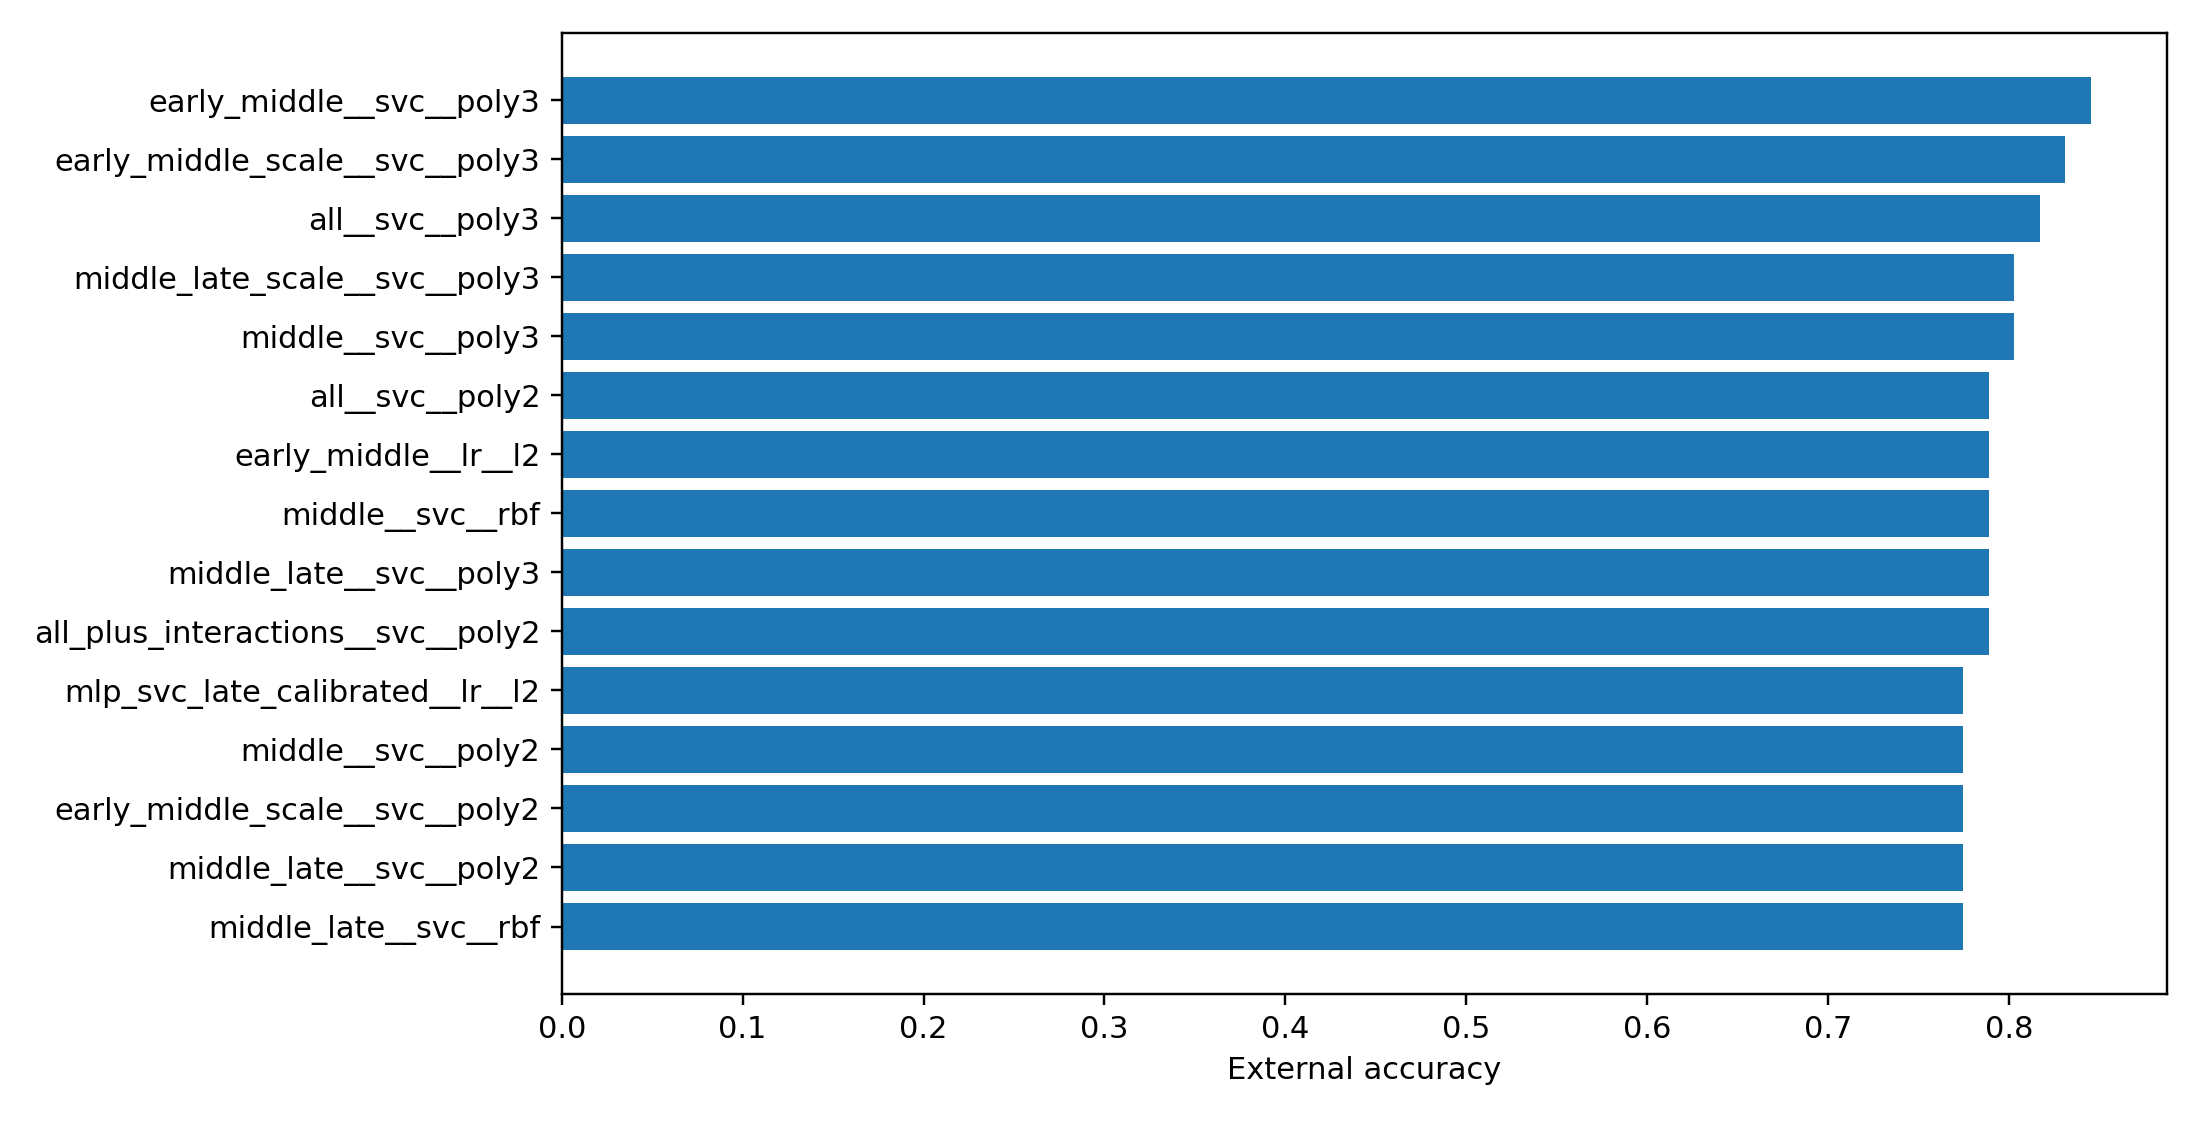

In [5]:
ranking = read_csv('stagev5_model_ranking_by_external_accuracy.csv')
if not ranking.empty:
    cols = [c for c in ['model_name', 'group', 'feature_block', 'accuracy', 'balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'roc_auc', 'pr_auc', 'mcc'] if c in ranking]
    display(ranking[cols].head(30))
show_png('fig01_model_ranking_external_accuracy.png', 'External accuracy ranking')

## 5. Selected model performance

In [6]:
if not ranking.empty:
    selected_model = str(ranking.iloc[0]['model_name'])
    display(Markdown(f'**Selected model:** `{selected_model}`'))
    display(ranking.head(1))
else:
    selected_model = None
    display(Markdown('**Selected model:** file not found / not generated yet'))
show_md('stagev5_selected_model_summary.md')

**Selected model:** `early_middle__svc__poly3`

,model_name,group,feature_block,mechanism_consistent,best_params,accuracy,balanced_accuracy,sensitivity,specificity,precision,...,roc_auc,pr_auc,mcc,log_loss,brier,tn,fp,fn,tp,threshold
0,early_middle__svc__poly3,two_stage_raw,early_middle,False,"{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",0.84507,0.846429,0.942857,0.75,0.785714,...,0.855556,0.849592,0.704702,0.595263,0.174924,27,9,2,33,0.5


# stagev5 selected model summary

## Selection protocol

- Feature sources: E/M from stagev2; L from stagev4_unmasked P4/F8.
- L raw model features: 8
- L auxiliary diagnostic features: 0
- L auxiliary features used in model: false
- L activation for interaction blocks: raw_F8_mean
- Training: stagev2 classifier panel, GridSearchCV, repeated stratified 10-fold CV (10×1).
- Ranking: held-out external accuracy. The external set was not used for fit, scaling, imputation, or BM25 fitting.

## Selected model

| model_name               | group         | feature_block   |   accuracy |   balanced_accuracy |   sensitivity |   specificity |       f1 |   roc_auc |   pr_auc |      mcc |   tn |   fp |   fn |   tp |
|:-------------------------|:--------------|:----------------|-----------:|--------------------:|--------------:|--------------:|---------:|----------:|---------:|---------:|-----:|-----:|-----:|-----:|
| early_middle__svc__poly3 | two_stage_raw | early_middle    |    0.84507 |            0.846429 |      0.942857 |          0.75 | 0.857143 |  0.855556 | 0.849592 | 0.704702 |   27 |    9 |    2 |   33 |

## Stage/subgroup diagnostic

| model_name               | severity_group   |   n |   accuracy |   mean_p_ad |   false_negatives |   false_positives |
|:-------------------------|:-----------------|----:|-----------:|------------:|------------------:|------------------:|
| early_middle__svc__poly3 | AD_high_MMSE     |   8 |   1        |    0.825218 |                 0 |                 0 |
| early_middle__svc__poly3 | control          |  36 |   0.75     |    0.394966 |                 0 |                 9 |
| early_middle__svc__poly3 | early            |   6 |   0.833333 |    0.762936 |                 1 |                 0 |
| early_middle__svc__poly3 | late             |   7 |   1        |    0.930051 |                 0 |                 0 |
| early_middle__svc__poly3 | middle           |  14 |   0.928571 |    0.818436 |                 1 |                 0 |


## 6. Bootstrap CI

,model_name,metric,bootstrap_mean,ci_low,ci_high,n_boot
232,early_middle__svc__poly3,accuracy,0.840775,0.760211,0.915493,200


### Selected model bootstrap external accuracy CI

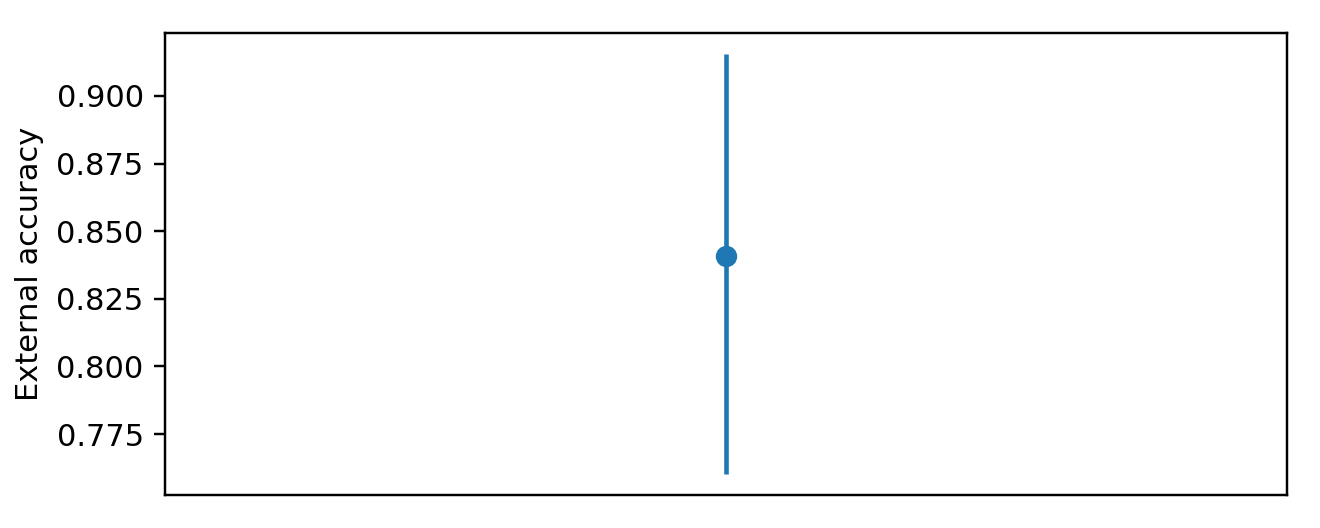

In [7]:
boot = read_csv('stagev5_bootstrap_ci.csv')
if selected_model and not boot.empty and {'model_name', 'metric'}.issubset(boot.columns):
    display(boot[(boot['model_name'].eq(selected_model)) & (boot['metric'].eq('accuracy'))])
elif not boot.empty:
    display(boot.head(20))
show_png('fig07_bootstrap_external_accuracy_ci.png', 'Selected model bootstrap external accuracy CI')

## 7. Feature block comparison

,feature_block,accuracy
4,early_middle,0.845070
5,early_middle_scale,0.830986
0,all,0.816901
7,middle,0.802817
9,middle_late_scale,0.802817
8,middle_late,0.788732
1,all_plus_interactions,0.788732
2,early,0.774648
10,sequential_interactions,0.774648
3,early_late,0.718310


### Best external accuracy by feature block

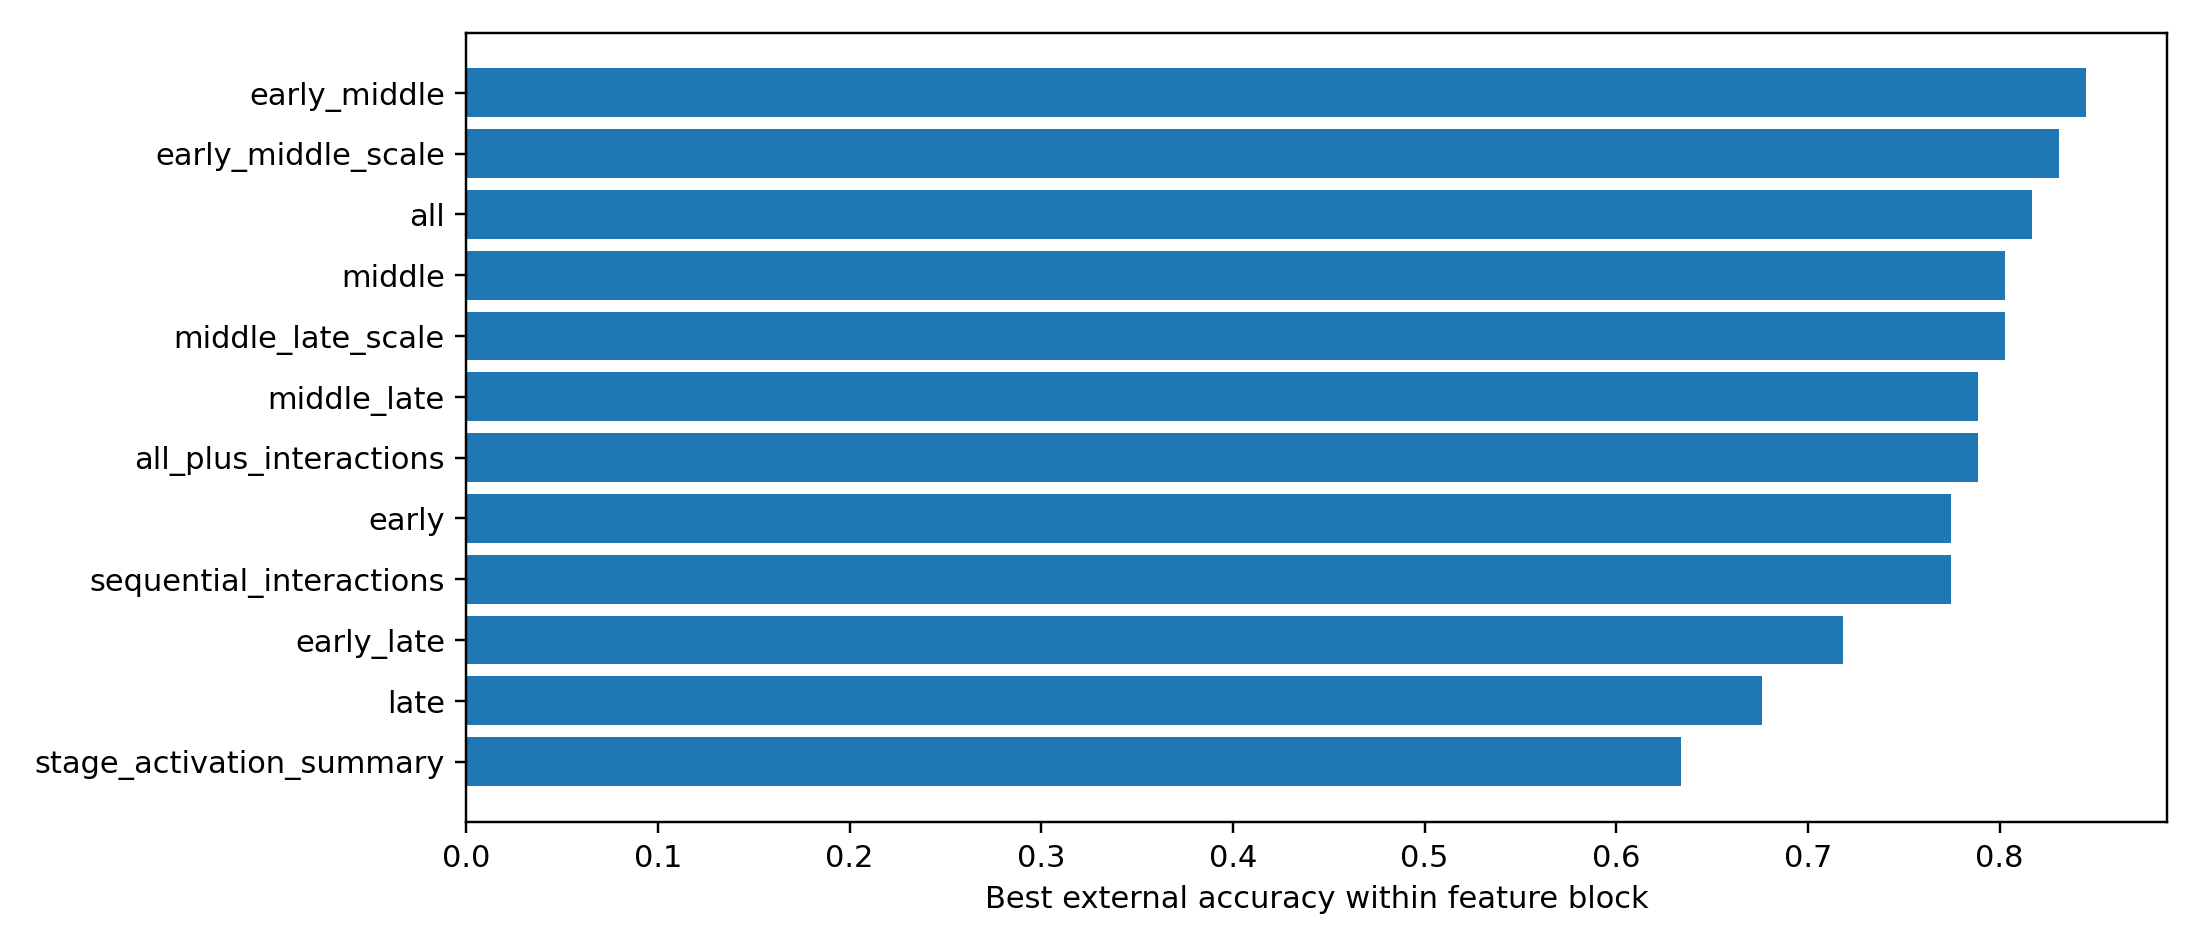

In [8]:
if not ranking.empty and {'feature_block', 'accuracy'}.issubset(ranking.columns):
    block = ranking.groupby('feature_block', as_index=False)['accuracy'].max().sort_values('accuracy', ascending=False)
    display(block)
else:
    display(Markdown('Feature block comparison unavailable.'))
show_png('fig02_feature_block_comparison.png', 'Best external accuracy by feature block')

## 8. Confusion matrix

,Pred control,Pred AD
True control,27,9
True AD,2,33


### Selected model external confusion matrix

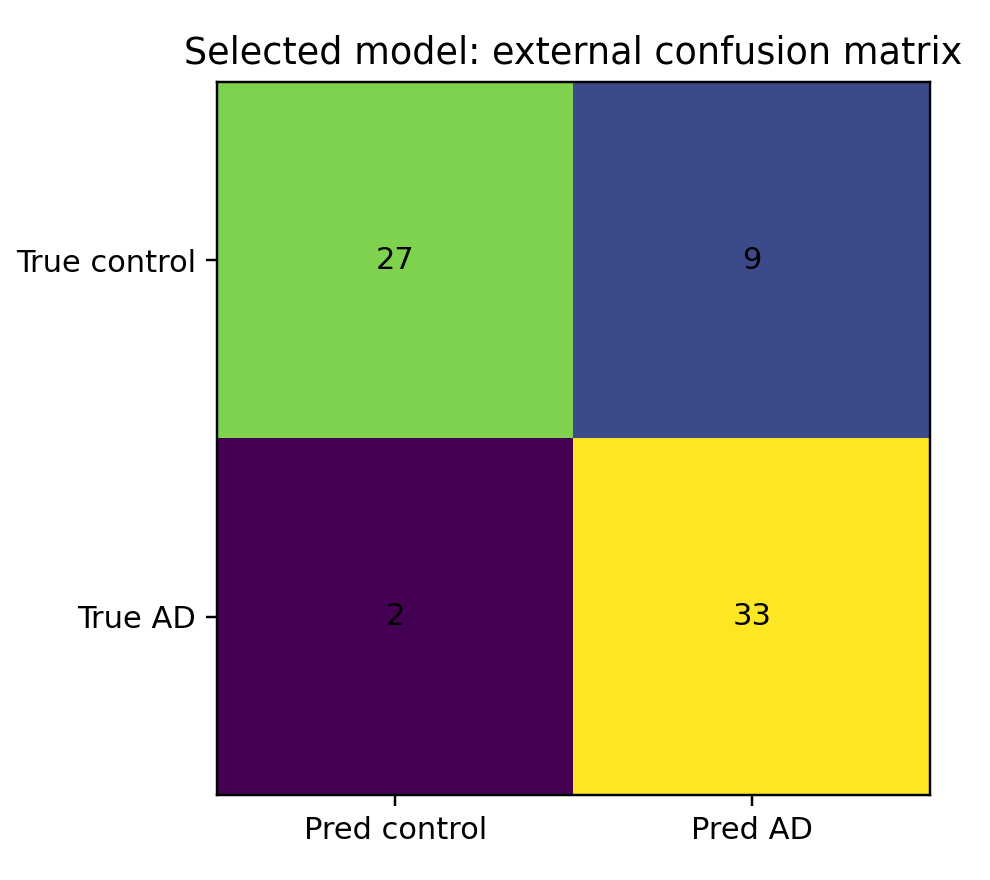

In [9]:
preds = read_csv('stagev5_test_predictions_all_models.csv')
if selected_model and not preds.empty and {'model_name', 'y_true', 'y_pred'}.issubset(preds.columns):
    selected_preds = preds[preds['model_name'].eq(selected_model)].copy()
    cm = pd.crosstab(selected_preds['y_true'], selected_preds['y_pred']).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    cm.index = ['True control', 'True AD']
    cm.columns = ['Pred control', 'Pred AD']
    display(cm)
else:
    display(Markdown('External confusion matrix unavailable.'))
show_png('fig03_selected_model_confusion_matrix.png', 'Selected model external confusion matrix')

## 9. Severity / stage subgroup accuracy

,model_name,severity_group,n,accuracy,mean_p_ad,false_negatives,false_positives
190,early_middle__svc__poly3,AD_high_MMSE,8,1.000000,0.825218,0,0
191,early_middle__svc__poly3,control,36,0.750000,0.394966,0,9
192,early_middle__svc__poly3,early,6,0.833333,0.762936,1,0
193,early_middle__svc__poly3,late,7,1.000000,0.930051,0,0
194,early_middle__svc__poly3,middle,14,0.928571,0.818436,1,0


### Selected model severity subgroup accuracy

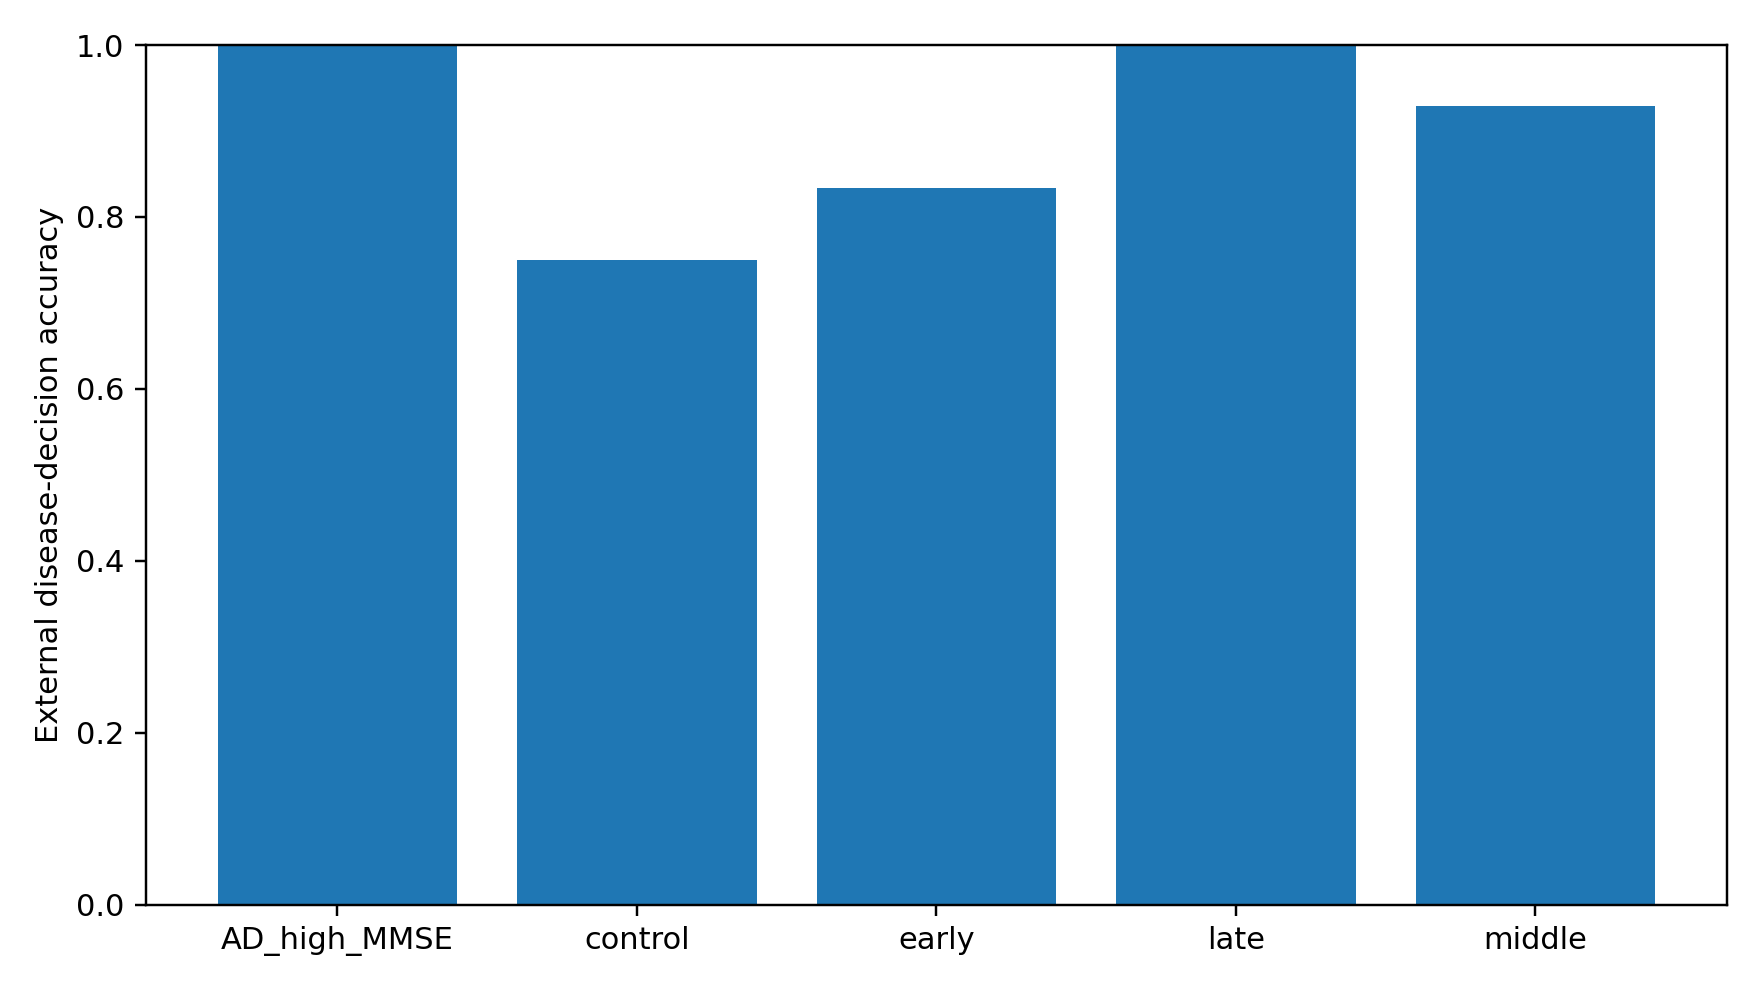

In [10]:
subgroup = read_csv('stagev5_stage_subgroup_accuracy.csv')
if selected_model and not subgroup.empty and 'model_name' in subgroup:
    display(subgroup[subgroup['model_name'].eq(selected_model)])
elif not subgroup.empty:
    display(subgroup)
show_png('fig05_stage_subgroup_accuracy.png', 'Selected model severity subgroup accuracy')

## 10. Error analysis and hard cases

,sample_id,y_true,label_disease,label_early,label_middle,label_late,label_normal,label_mild,label_moderate,label_severe,...,s_E,s_M,s_L,s_E_M,s_M_L,s_E_M_L,p_MLP,p_SVC,p_MLP_L,p_SVC_L
0,TEST_0041,1,1,1,0,0,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TEST_0017,1,1,0,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TEST_0062,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TEST_0060,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEST_0037,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,TEST_0022,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,TEST_0027,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,TEST_0058,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,TEST_0069,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,TEST_0030,0,0,0,0,0,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Selected model external error types

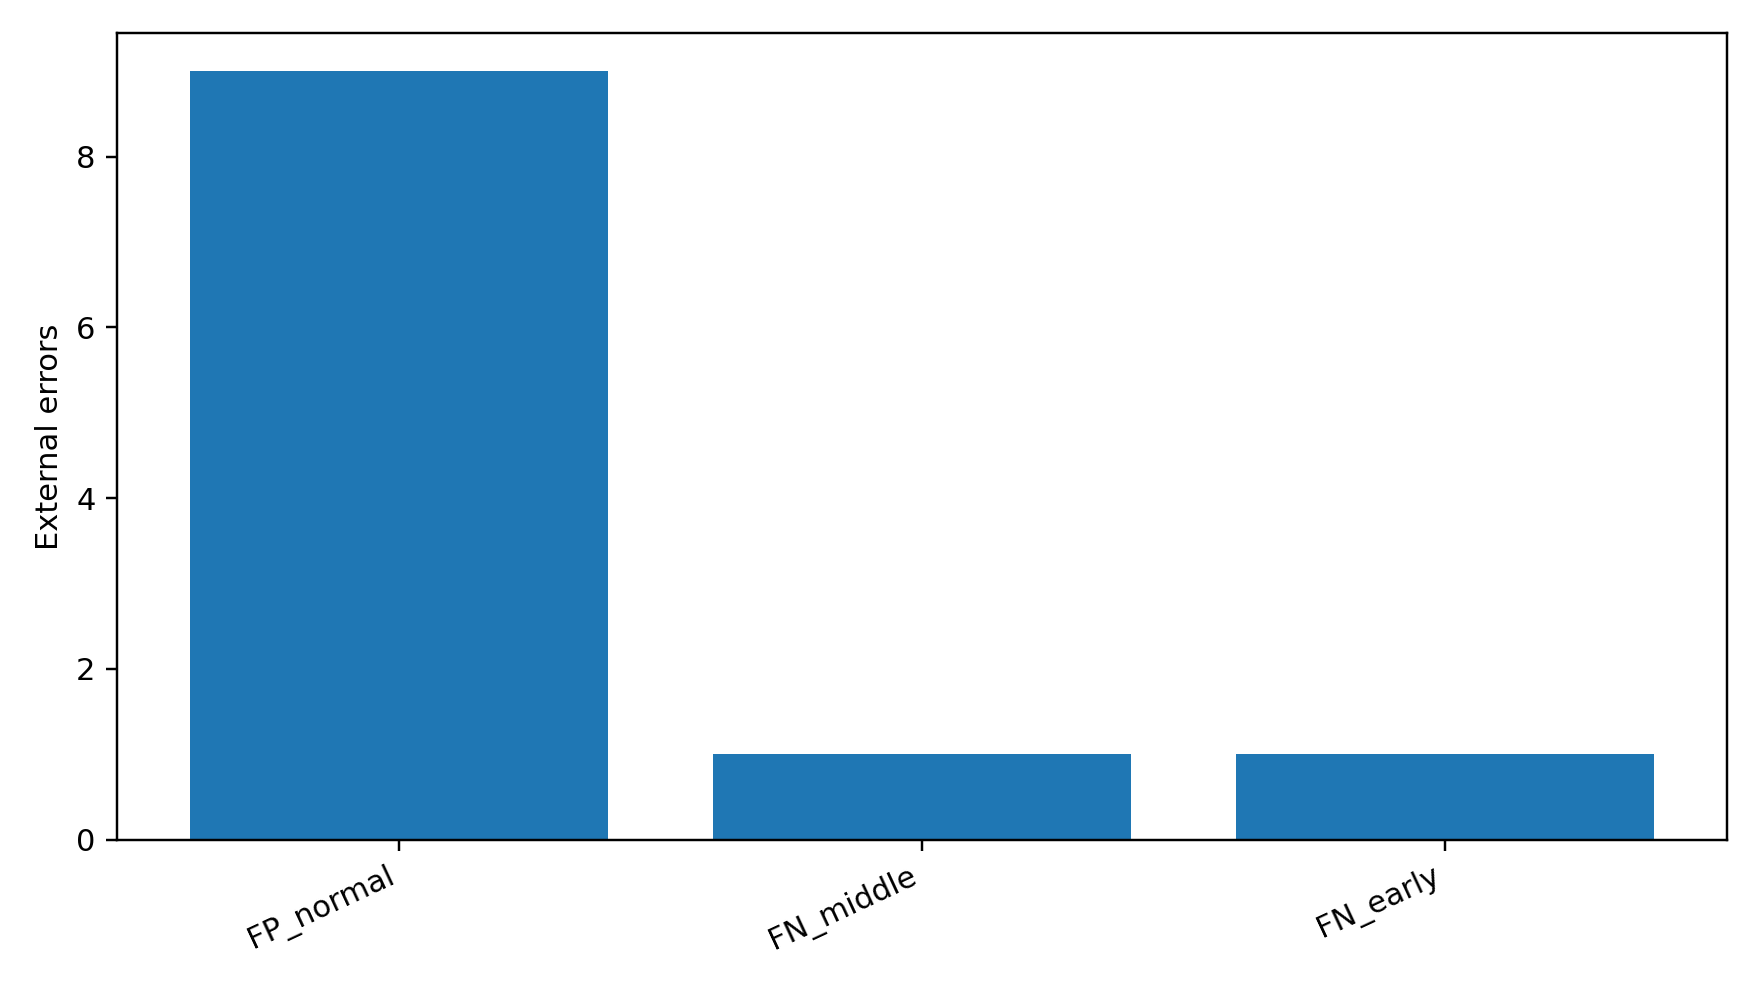

In [11]:
errors = read_csv('stagev5_error_analysis.csv')
if not errors.empty:
    display(errors.head(50))
else:
    display(Markdown('No selected-model error table found, or no errors were generated.'))
show_png('fig06_error_type_distribution.png', 'Selected model external error types')

## 11. Leakage and reproducibility check

In [12]:
leakage = read_json('stagev5_leakage_check.json')
if leakage:
    display(pd.json_normalize(leakage))
summary = read_json('stagev5_final_run_summary.json')
if summary:
    display(pd.json_normalize(summary))

,standard_scaler_inside_pipeline,imputer_inside_pipeline,stage_scores_inner_oof,mlp_svc_late_inner_oof,external_accuracy_used_for_model_selection,external_set_role,mmse_used_as_input_feature,tfidf_used,rbf_svm_used,historical_outputs_reused,run_seconds
0,True,True,True,True,True,"held-out external validation, not unbiased fin...",False,False,True,False,1837.866545


,selected_model,feature_block,external_accuracy,external_balanced_accuracy,n_models_completed,selection_metric,figures,feature_dimensions.n_E,feature_dimensions.n_M,feature_dimensions.n_L,...,feature_dimensions.late_all_related_cols,feature_dimensions.late_model_feature_count,feature_dimensions.late_diagnostic_column_count,feature_dimensions.late_auxiliary_used_in_model,feature_dimensions.late_auxiliary_columns_consistent,feature_dimensions.late_split_summaries,feature_dimensions.late_activation_policy,feature_dimensions.paths.E,feature_dimensions.paths.M,feature_dimensions.paths.L
0,early_middle__svc__poly3,early_middle,0.84507,0.846429,102,external_accuracy,"[fig01_model_ranking_external_accuracy.png, fi...",61,1024,8,...,"[late_sentence_structural_integrity, late_phra...",8,0,False,True,"[{'name': 'ad_LLM.csv', 'late_all_related_cols...",raw_F8_mean,[D:\research\H.L.Liang-Lab\Code\expore\stagev5...,[D:\research\H.L.Liang-Lab\Code\expore\stagev5...,[D:\research\H.L.Liang-Lab\Code\expore\stagev5...


## 12. Final concise conclusion

In [13]:
if selected_model and not ranking.empty:
    top = ranking.iloc[0]
    acc = top.get('accuracy', 'n/a')
    block = top.get('feature_block', 'n/a')
    display(Markdown(
        f'Stagev5 selects `{selected_model}` by held-out external accuracy. '
        f'The selected feature block is `{block}` and external accuracy is `{acc}`. '
        'The notebook is a read-only rendering of existing result artifacts.'
    ))
else:
    display(Markdown('Final conclusion unavailable because the ranking file was not found / not generated yet.'))

Stagev5 selects `early_middle__svc__poly3` by held-out external accuracy. The selected feature block is `early_middle` and external accuracy is `0.8450704225352113`. The notebook is a read-only rendering of existing result artifacts.